In [1]:
#Laboratorio 9: Datos Sinteticos

In [5]:
#Importar librerias
from faker import Faker
import pandas as pd
import random

In [6]:
pip install faker

Note: you may need to restart the kernel to use updated packages.


In [7]:
# Creamos una instancia de Faker 
fake = Faker("es_MX")

In [28]:
#Generamos datos sinteticos
datos = []
for i in range(100):
    datos.append({
        "id_usuario": i + 1,
        "nombre": fake.name(),
        "correo": fake.email(),
        "edad": random.randint(16,85),
        "seguidores": random.randint(100, 50000),
        "plataforma": random.choice(["Tiktok", "Instagram", "YouTube"]
            )
    })

In [29]:
df = pd.DataFrame(datos)

In [30]:
df.head()

,id_usuario,nombre,correo,edad,seguidores,plataforma
0,1,Eva Victoria Alemán,juan-carlos99@example.org,16,20208,YouTube
1,2,Esther María Lira Segovia,zgarcia@example.net,79,39590,YouTube
2,3,Karina Olivia Rolón Escobar,maria-luisa42@example.org,55,40994,YouTube
3,4,Ing. Agustín Barrera,itzel26@example.org,50,48618,Tiktok
4,5,Aurora Blanca León,solorzanoisaac@example.org,19,31424,YouTube


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_usuario  100 non-null    int64 
 1   nombre      100 non-null    object
 2   correo      100 non-null    object
 3   edad        100 non-null    int64 
 4   seguidores  100 non-null    int64 
 5   plataforma  100 non-null    object
dtypes: int64(3), object(3)
memory usage: 4.8+ KB


In [32]:
#Estadistica descriptiva 
df.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,100.000000,100,100,100.000000,100.00000,100
unique,NaN,100,100,NaN,NaN,3
top,NaN,Eva Victoria Alemán,juan-carlos99@example.org,NaN,NaN,YouTube
freq,NaN,1,1,NaN,NaN,42
mean,50.500000,NaN,NaN,48.970000,24533.11000,NaN
std,29.011492,NaN,NaN,19.960291,14360.71954,NaN
min,1.000000,NaN,NaN,16.000000,556.00000,NaN
25%,25.750000,NaN,NaN,32.750000,11392.25000,NaN
50%,50.500000,NaN,NaN,46.500000,23489.50000,NaN
75%,75.250000,NaN,NaN,67.000000,36055.25000,NaN


In [33]:
#Importar librerias para graficar
import seaborn as sns
import matplotlib.pyplot as plt

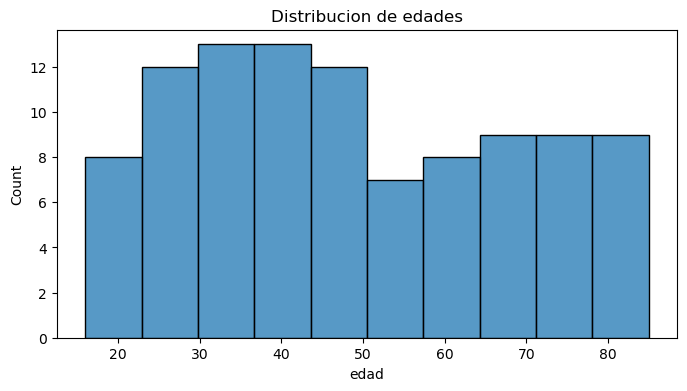

In [34]:
#Distrribucion de edades
plt.figure(figsize=(8,4))
sns.histplot(
    df["edad"],
    bins=10
)
plt.title("Distribucion de edades")
plt.show()

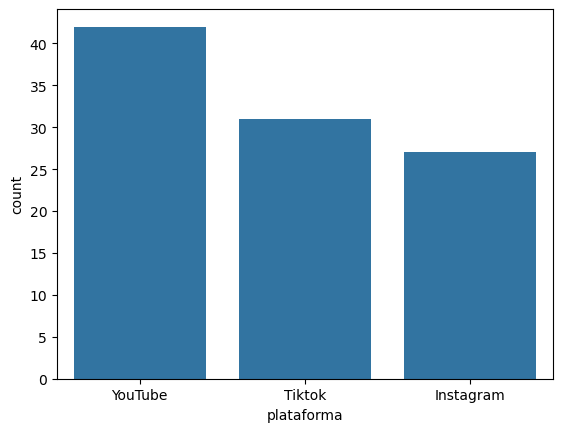

In [35]:
#Usuarios por plataforma
sns.countplot(
    x="plataforma",
    data=df
)
plt.show()

In [36]:
#Generamos una copia para contaminarla
df_sucio = df.copy()

In [37]:
#Le colocamos valores nulos
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"nombre"] = None

In [38]:
df_sucio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_usuario  100 non-null    int64 
 1   nombre      95 non-null     object
 2   correo      100 non-null    object
 3   edad        100 non-null    int64 
 4   seguidores  100 non-null    int64 
 5   plataforma  100 non-null    object
dtypes: int64(3), object(3)
memory usage: 4.8+ KB


In [39]:
#Edades invalidas
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"edad"] = -10

In [40]:
df_sucio.describe()["edad"]

count    100.000000
mean      45.210000
std       23.024929
min      -10.000000
25%       30.500000
50%       43.500000
75%       64.000000
max       85.000000
Name: edad, dtype: float64

In [41]:
#Seguidores imposibles
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"seguidores"] = 5000000

In [42]:
df_sucio.describe()["seguidores"]

count    1.000000e+02
mean     2.736361e+05
std      1.089854e+06
min      5.560000e+02
25%      1.290800e+04
50%      2.590050e+04
75%      3.882650e+04
max      5.000000e+06
Name: seguidores, dtype: float64

In [43]:
#Generamos correo invalidos
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"correo"] = "correo_invalido"

In [44]:
df_sucio.describe(include=["object"])

,nombre,correo,plataforma
count,95,100,100
unique,95,96,3
top,Eva Victoria Alemán,correo_invalido,YouTube
freq,1,5,42


In [45]:
df_sucio.isnull().sum()

id_usuario    0
nombre        5
correo        0
edad          0
seguidores    0
plataforma    0
dtype: int64

In [46]:
df_sucio.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,100.000000,95,100,100.000000,1.000000e+02,100
unique,NaN,95,96,NaN,NaN,3
top,NaN,Eva Victoria Alemán,correo_invalido,NaN,NaN,YouTube
freq,NaN,1,5,NaN,NaN,42
mean,50.500000,NaN,NaN,45.210000,2.736361e+05,NaN
std,29.011492,NaN,NaN,23.024929,1.089854e+06,NaN
min,1.000000,NaN,NaN,-10.000000,5.560000e+02,NaN
25%,25.750000,NaN,NaN,30.500000,1.290800e+04,NaN
50%,50.500000,NaN,NaN,43.500000,2.590050e+04,NaN
75%,75.250000,NaN,NaN,64.000000,3.882650e+04,NaN
